# Сравнение моделей машинного обучения

Лабораторная работа №4.

**Задача:** многоклассовая классификация — предсказать вид пингвина (`species`).

**Датасет:** `seaborn.load_dataset('penguins')` — числовые и категориальные признаки, есть пропуски.

## 1) Описание набора данных

- Документация Seaborn: https://seaborn.pydata.org/generated/seaborn.load_dataset.html
- Источник: Palmer Penguins (Gorman & Robinson, 2014)

Набор содержит **344** записи. Целевая переменная — `species` (Adelie, Chinstrap, Gentoo).

| Тип | Признаки |
|-----|----------|
| Числовые | `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g` |
| Категориальные | `sex`, `island` |

В данных есть **пропуски** (в основном в `sex` и измерениях клюва), что позволяет показать этап предобработки.

## Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

%matplotlib inline
sns.set(style="ticks")

## Загрузка и первичный осмотр

In [2]:
df = sns.load_dataset("penguins")
print("Размер:", df.shape)
display(df.head())
print("\nПропуски:")
display(df.isna().sum().sort_values(ascending=False).to_frame("count"))
print("\nРаспределение классов:")
print(df["species"].value_counts())

Размер: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female



Пропуски:


,count
sex,11
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
species,0
island,0



Распределение классов:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


## Предобработка данных

1. Удаляем строки без целевой переменной.
2. Заполняем пропуски: медиана для числовых, мода для категориальных.
3. Кодируем категории через `OneHotEncoder`.
4. Масштабируем числовые признаки (`StandardScaler`) — необходимо для логистической регрессии и SVM.

In [3]:
TARGET = "species"
NUMERIC_FEATURES = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
CATEGORICAL_FEATURES = ["sex", "island"]

data = df.dropna(subset=[TARGET])
y = data[TARGET]
X = data[NUMERIC_FEATURES + CATEGORICAL_FEATURES]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, NUMERIC_FEATURES),
        ("cat", categorical_transformer, CATEGORICAL_FEATURES),
    ]
)

print("Признаки X:", list(X.columns))
print("Распределение классов:")
print(y.value_counts(normalize=True).round(3))

Признаки X: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex', 'island']
Распределение классов:
species
Adelie       0.442
Gentoo       0.360
Chinstrap    0.198
Name: proportion, dtype: float64


## Разделение на обучающую и тестовую выборки

Используем `train_test_split` с долей теста 25% и стратификацией по классам.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

print(f"Обучающая выборка: {X_train.shape[0]} объектов")
print(f"Тестовая выборка:   {X_test.shape[0]} объектов")

Обучающая выборка: 258 объектов
Тестовая выборка:   86 объектов


## Обучение моделей

Обучаем три модели:
- **Логистическая регрессия** — линейная модель для классификации;
- **SVM** (метод опорных векторов) с RBF-ядром;
- **Дерево решений** с ограничением глубины для интерпретируемости.

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(kernel="rbf", random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=42),
}

pipelines = {}
for name, model in models.items():
    pipelines[name] = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", model),
        ]
    )
    pipelines[name].fit(X_train, y_train)
    print(f"{name}: обучена")

Logistic Regression: обучена
SVM: обучена
Decision Tree: обучена


## Оценка качества моделей

Для многоклассовой классификации используем две метрики:
- **Accuracy** — доля верных предсказаний;
- **F1-score (macro)** — среднее F1 по классам, учитывает баланс precision/recall.

In [6]:
results = []
predictions = {}

for name, pipe in pipelines.items():
    y_pred = pipe.predict(X_test)
    predictions[name] = y_pred
    results.append({
        "Модель": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 (macro)": f1_score(y_test, y_pred, average="macro"),
    })

results_df = pd.DataFrame(results).set_index("Модель")
display(results_df.round(4))

best_model = results_df["F1 (macro)"].idxmax()
print(f"\nЛучшая модель по F1 (macro): {best_model}")

,Accuracy,F1 (macro)
Модель,,
Logistic Regression,1.0000,1.0000
SVM,1.0000,1.0000
Decision Tree,0.9884,0.9903



Лучшая модель по F1 (macro): Logistic Regression


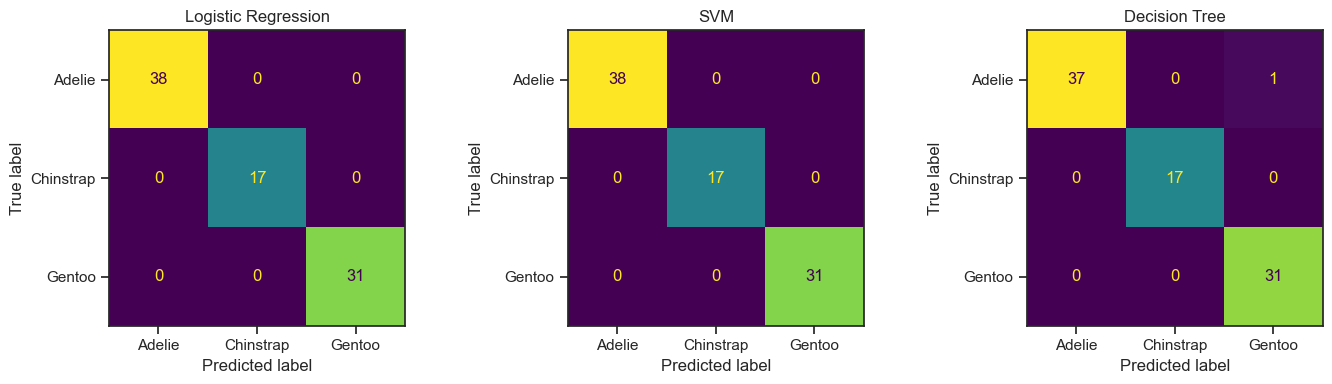

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, name in zip(axes, pipelines):
    ConfusionMatrixDisplay.from_predictions(
        y_test, predictions[name],
        ax=ax, colorbar=False,
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [8]:
for name, pipe in pipelines.items():
    print(f"\n{'=' * 50}")
    print(name)
    print("=" * 50)
    print(classification_report(y_test, predictions[name]))


Logistic Regression
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        38
   Chinstrap       1.00      1.00      1.00        17
      Gentoo       1.00      1.00      1.00        31

    accuracy                           1.00        86
   macro avg       1.00      1.00      1.00        86
weighted avg       1.00      1.00      1.00        86


SVM
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        38
   Chinstrap       1.00      1.00      1.00        17
      Gentoo       1.00      1.00      1.00        31

    accuracy                           1.00        86
   macro avg       1.00      1.00      1.00        86
weighted avg       1.00      1.00      1.00        86


Decision Tree
              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.99        38
   Chinstrap       1.00      1.00      1.00        17
      Gentoo       0.97      1.00 

## Важность признаков (дерево решений)

Для дерева решений `feature_importances_` показывает, какие признаки чаще всего используются для разбиений.

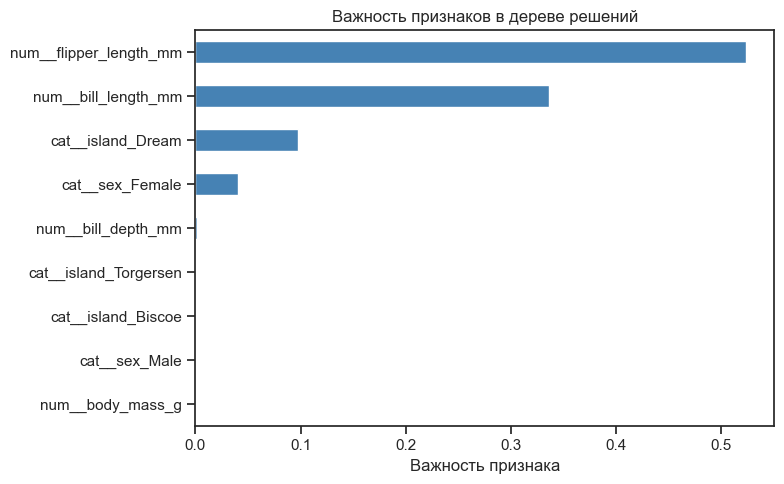

Топ-5 признаков:


,importance
num__flipper_length_mm,0.524256
num__bill_length_mm,0.336560
cat__island_Dream,0.097301
cat__sex_Female,0.040446
num__bill_depth_mm,0.001437


In [9]:
dt_pipe = pipelines["Decision Tree"]
dt_model = dt_pipe.named_steps["model"]
feature_names = dt_pipe.named_steps["preprocess"].get_feature_names_out()

importance = (
    pd.Series(dt_model.feature_importances_, index=feature_names)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 5))
importance.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Важность признака")
ax.set_title("Важность признаков в дереве решений")
plt.tight_layout()
plt.show()

print("Топ-5 признаков:")
display(importance.sort_values(ascending=False).head().to_frame("importance"))

## Визуализация и правила дерева решений

Графическое представление дерева и текстовые правила (`export_text`).

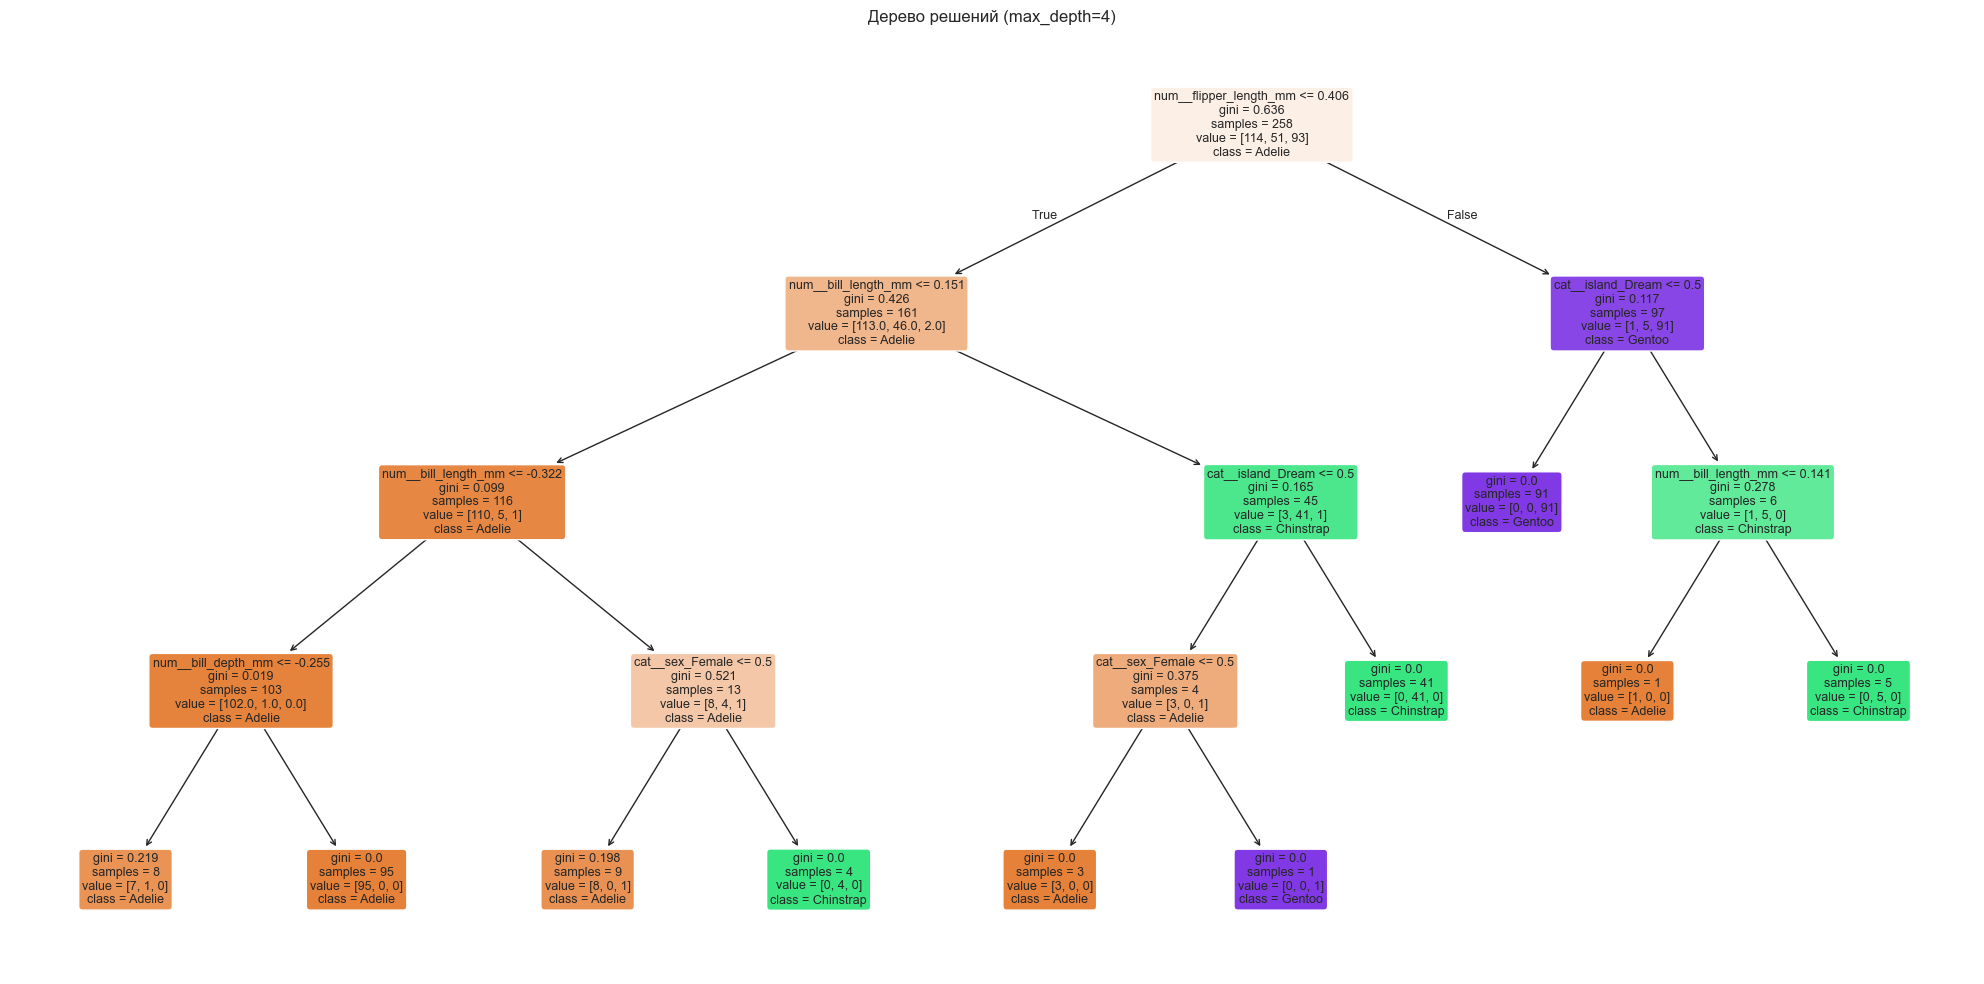

In [10]:
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=dt_model.classes_,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
)
ax.set_title("Дерево решений (max_depth=4)")
plt.tight_layout()
plt.show()

In [11]:
tree_rules = export_text(dt_model, feature_names=list(feature_names))
print(tree_rules)

|--- num__flipper_length_mm <= 0.41
|   |--- num__bill_length_mm <= 0.15
|   |   |--- num__bill_length_mm <= -0.32
|   |   |   |--- num__bill_depth_mm <= -0.25
|   |   |   |   |--- class: Adelie
|   |   |   |--- num__bill_depth_mm >  -0.25
|   |   |   |   |--- class: Adelie
|   |   |--- num__bill_length_mm >  -0.32
|   |   |   |--- cat__sex_Female <= 0.50
|   |   |   |   |--- class: Adelie
|   |   |   |--- cat__sex_Female >  0.50
|   |   |   |   |--- class: Chinstrap
|   |--- num__bill_length_mm >  0.15
|   |   |--- cat__island_Dream <= 0.50
|   |   |   |--- cat__sex_Female <= 0.50
|   |   |   |   |--- class: Adelie
|   |   |   |--- cat__sex_Female >  0.50
|   |   |   |   |--- class: Gentoo
|   |   |--- cat__island_Dream >  0.50
|   |   |   |--- class: Chinstrap
|--- num__flipper_length_mm >  0.41
|   |--- cat__island_Dream <= 0.50
|   |   |--- class: Gentoo
|   |--- cat__island_Dream >  0.50
|   |   |--- num__bill_length_mm <= 0.14
|   |   |   |--- class: Adelie
|   |   |--- num__bill

## Выводы

1. Все три модели показывают высокое качество на тестовой выборке — признаки Palmer Penguins хорошо разделяют виды.
2. Линейная (логистическая регрессия) и нелинейная (SVM) модели сопоставимы по метрикам.
3. Дерево решений немного уступает, но остаётся интерпретируемым: наиболее важны `flipper_length_mm` и `bill_length_mm`.
4. Для задач, где важна объяснимость, предпочтительно дерево решений; для максимальной точности — SVM или логистическая регрессия с масштабированием.